# Régression Linéaire — Salaire en fonction des Années d'Expérience

> Modèle entraîné **from scratch** par descente de gradient, avec normalisation z-score,
> validation croisée k-fold, analyse complète des résidus et intervalles de confiance.

**Dataset :** 30 observations · 2 variables · `YearsExperience` → `Salary`

## 1. Imports

In [1]:
# Bibliothèques standard
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats                        # Tests statistiques (Shapiro-Wilk, Q-Q)
from sklearn.model_selection import train_test_split, KFold  # Split + validation croisée
from sklearn.linear_model import LinearRegression            # Référence sklearn

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
SEED = 42
np.random.seed(SEED)

## 2. Chargement & exploration des données

In [2]:
data = pd.read_csv("Salary_dataset.csv", index_col=0)
print(f"Dimensions : {data.shape[0]} lignes x {data.shape[1]} colonnes")
print(f"Valeurs manquantes : {data.isnull().sum().sum()}")
data.head()

Dimensions : 30 lignes x 2 colonnes
Valeurs manquantes : 0


,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [3]:
print('-' * 50)
print('Statistiques descriptives')
print('-' * 50)
print(data.describe().round(2))
r_pearson = data['YearsExperience'].corr(data['Salary'])
print(f"\nCorrelation de Pearson r = {r_pearson:.4f}")

--------------------------------------------------
Statistiques descriptives
--------------------------------------------------
       YearsExperience     Salary
count            30.00      30.00
mean              5.41   76004.00
std               2.84   27414.43
min               1.20   37732.00
25%               3.30   56721.75
50%               4.80   65238.00
75%               7.80  100545.75
max              10.60  122392.00

Correlation de Pearson r = 0.9782


## 3. Visualisation initiale

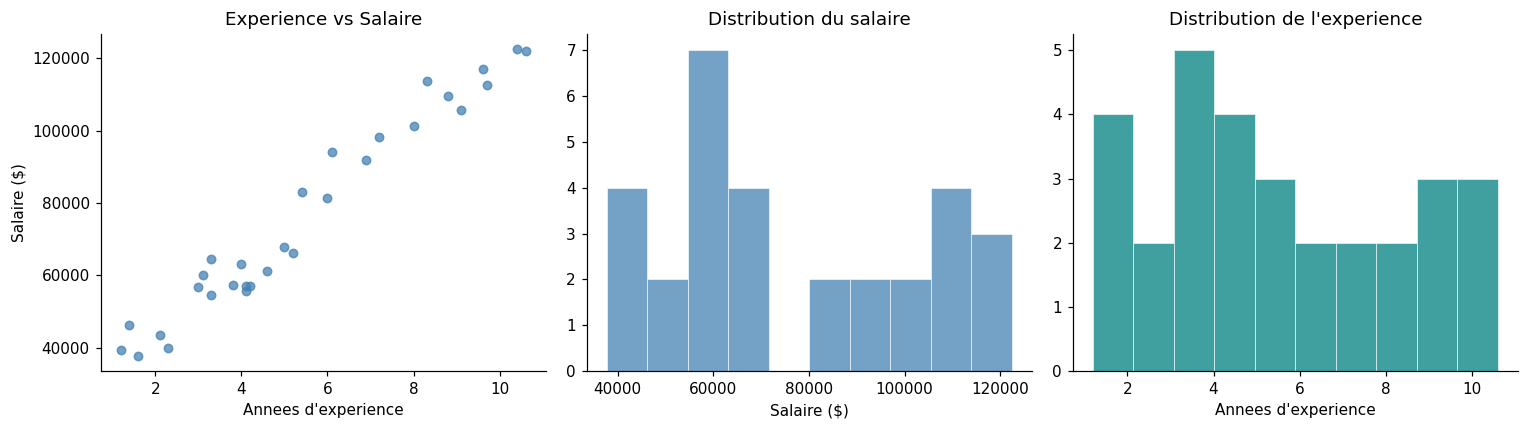

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(data['YearsExperience'], data['Salary'], alpha=0.75, s=30, color='steelblue')
axes[0].set_title("Experience vs Salaire")
axes[0].set_xlabel("Annees d'experience")
axes[0].set_ylabel('Salaire ($)')

axes[1].hist(data['Salary'], bins=10, color='steelblue', alpha=0.75, edgecolor='white', lw=0.5)
axes[1].set_title('Distribution du salaire')
axes[1].set_xlabel('Salaire ($)')

axes[2].hist(data['YearsExperience'], bins=10, color='teal', alpha=0.75, edgecolor='white', lw=0.5)
axes[2].set_title("Distribution de l'experience")
axes[2].set_xlabel("Annees d'experience")

plt.tight_layout()
plt.show()

## 4. Separation train / test & normalisation z-score

In [5]:
x = data['YearsExperience'].values
y = data['Salary'].values

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=SEED
)
print(f"Train : {len(x_train)} obs. | Test : {len(x_test)} obs.")

# Stats calculees UNIQUEMENT sur le train -> aucun data leakage
x_mean, x_std = x_train.mean(), x_train.std()
y_mean, y_std = y_train.mean(), y_train.std()

x_train_n = (x_train - x_mean) / x_std
y_train_n = (y_train - y_mean) / y_std
x_test_n  = (x_test  - x_mean) / x_std   # Memes parametres du train
y_test_n  = (y_test  - y_mean) / y_std

print(f"x_train_n -> mean = {x_train_n.mean():.2e}  std = {x_train_n.std():.4f}")

Train : 24 obs. | Test : 6 obs.
x_train_n -> mean = -2.59e-16  std = 1.0000


## 5. Implementation from scratch : cout & descente de gradient

In [6]:
def cost_function(x, y, b, w):
    """MSE/2 — facilite le calcul du gradient."""
    m = len(x)
    residuals = w * x + b - y
    return np.sum(residuals ** 2) / (2 * m)


def gradient_descent_step(x, y, w, b, lr):
    """Une iteration de la descente de gradient (batch)."""
    m   = len(x)
    res = w * x + b - y          # Residus
    dw  = (1 / m) * np.sum(res * x)  # dL/dw
    db  = (1 / m) * np.sum(res)       # dL/db
    w  -= lr * dw
    b  -= lr * db
    return b, w


def train_model(x_n, y_n, lr=0.01, max_iter=10_000, tol=1e-9):
    """Entraine le modele. Retourne (b, w, historique_cout, iteration_convergence)."""
    b, w = 0.0, 0.0
    history = []
    converged_at = max_iter
    for i in range(max_iter):
        b, w = gradient_descent_step(x_n, y_n, w, b, lr)
        c = cost_function(x_n, y_n, b, w)
        history.append(c)
        if i > 0 and abs(history[-2] - c) < tol:
            converged_at = i
            break
    return b, w, history, converged_at

## 6. Entrainement du modele

In [7]:
b_n, w_n, cost_history, conv_iter = train_model(
    x_train_n, y_train_n, lr=0.01, max_iter=10_000, tol=1e-9
)

# Denormalisation
# y_n = w_n * x_n + b_n  =>  y = w_orig * x + b_orig
# w_orig = w_n * (y_std / x_std)
# b_orig = y_mean + y_std * b_n - w_orig * x_mean
w_orig = w_n * (y_std / x_std)
b_orig = y_mean + y_std * b_n - w_orig * x_mean

print(f"Convergence       : iteration {conv_iter:,}")
print(f"Pente  w (orig.)  : {w_orig:.4f} $/an")
print(f"Biais  b (orig.)  : {b_orig:.4f} $")
print(f"Equation          : y_hat = {w_orig:.2f} x + {b_orig:.2f}")

Convergence       : iteration 800
Pente  w (orig.)  : 9420.8091 $/an
Biais  b (orig.)  : 24396.0968 $
Equation          : y_hat = 9420.81 x + 24396.10


## 7. Evaluation : metriques R2, RMSE, MAE

In [8]:
def evaluate(x, y, b, w, label=''):
    """Calcule et affiche R2, RMSE et MAE."""
    preds     = w * x + b
    residuals = y - preds
    mse       = np.mean(residuals ** 2)
    rmse      = np.sqrt(mse)
    mae       = np.mean(np.abs(residuals))
    ss_res    = np.sum(residuals ** 2)
    ss_tot    = np.sum((y - y.mean()) ** 2)
    r2        = 1 - ss_res / ss_tot
    print(f"  [{label:^6}]  R2 = {r2:.4f}   RMSE = {rmse:,.2f} $   MAE = {mae:,.2f} $")
    return r2, rmse, mae, preds, residuals


print('-' * 58)
print('Performances en espace original')
print('-' * 58)
r2_tr, rmse_tr, mae_tr, preds_train, res_train = evaluate(x_train, y_train, b_orig, w_orig, 'Train')
r2_te, rmse_te, mae_te, preds_test,  res_test  = evaluate(x_test,  y_test,  b_orig, w_orig, 'Test')
print('-' * 58)
delta_r2 = r2_tr - r2_te
msg = 'leger overfitting' if delta_r2 > 0.05 else 'pas d overfitting significatif'
print(f"  Delta R2 (train - test) = {delta_r2:.4f}  <- {msg}")

----------------------------------------------------------
Performances en espace original
----------------------------------------------------------
  [Train ]  R2 = 0.9645   RMSE = 5,205.99 $   MAE = 4,222.79 $
  [ Test ]  R2 = 0.9024   RMSE = 7,059.64 $   MAE = 6,285.70 $
----------------------------------------------------------
  Delta R2 (train - test) = 0.0621  <- leger overfitting


## 8. Courbe d'apprentissage

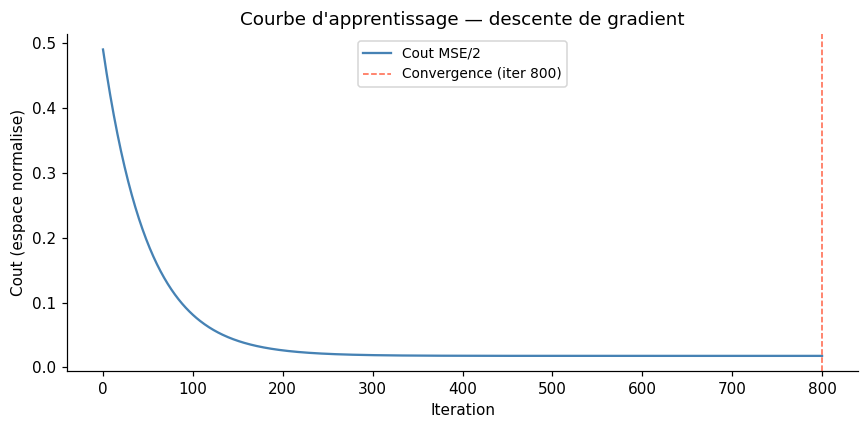

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color='steelblue', lw=1.5, label='Cout MSE/2')
plt.axvline(conv_iter, color='tomato', ls='--', lw=1, label=f'Convergence (iter {conv_iter})')
plt.xlabel('Iteration')
plt.ylabel('Cout (espace normalise)')
plt.title("Courbe d'apprentissage — descente de gradient")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 9. Droite de regression

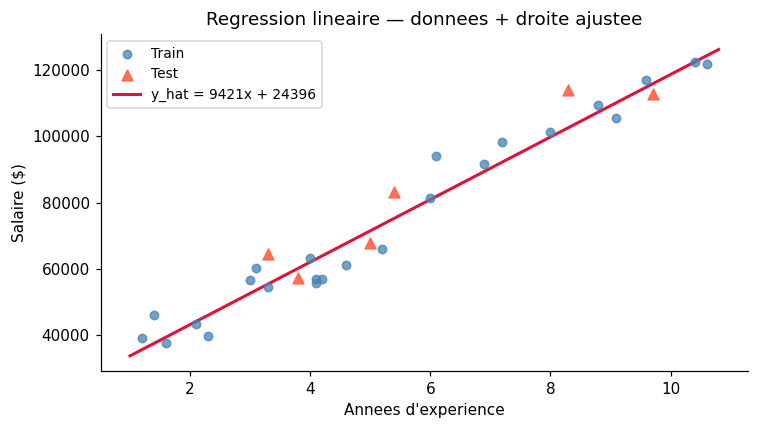

In [10]:
x_line = np.linspace(x.min() - 0.2, x.max() + 0.2, 300)
y_line = w_orig * x_line + b_orig

plt.figure(figsize=(7, 4))
plt.scatter(x_train, y_train, s=30, alpha=0.75, color='steelblue', label='Train', zorder=3)
plt.scatter(x_test,  y_test,  s=50, alpha=0.90, color='tomato', marker='^', label='Test', zorder=4)
plt.plot(x_line, y_line, color='crimson', lw=2,
         label=f"y_hat = {w_orig:.0f}x + {b_orig:.0f}")
plt.xlabel("Annees d'experience")
plt.ylabel('Salaire ($)')
plt.title('Regression lineaire — donnees + droite ajustee')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 10. Validation croisee k-fold

> Avec seulement 30 observations et 6 points en test, les metriques precedentes ont une forte variance d'echantillonnage. Un **k-fold a 5 plis** donne une estimation bien plus robuste.

Pour chaque pli, on reentrainement le modele from scratch (normalisation sur le train du pli, application au pli de validation).

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_r2, cv_rmse, cv_mae = [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(x), 1):
    xtr,  xval = x[train_idx], x[val_idx]
    ytr,  yval = y[train_idx], y[val_idx]

    # Normalisation z-score sur le train du pli
    xm, xs = xtr.mean(), xtr.std()
    ym, ys = ytr.mean(), ytr.std()
    xtr_n  = (xtr  - xm) / xs
    ytr_n  = (ytr  - ym) / ys

    # Entrainement from scratch
    b_f, w_f, _, _ = train_model(xtr_n, ytr_n)

    # Denormalisation
    wf = w_f * (ys / xs)
    bf = ym + ys * b_f - wf * xm

    # Evaluation sur le pli de validation
    pv  = wf * xval + bf
    res = yval - pv
    mse = np.mean(res ** 2)
    r2  = 1 - np.sum(res**2) / np.sum((yval - yval.mean())**2)
    cv_r2.append(r2)
    cv_rmse.append(np.sqrt(mse))
    cv_mae.append(np.mean(np.abs(res)))
    print(f"  Pli {fold} -> R2 = {r2:.4f}   RMSE = {np.sqrt(mse):,.0f} $   MAE = {np.mean(np.abs(res)):,.0f} $")

print('-' * 56)
print(f"  Moyenne  -> R2   = {np.mean(cv_r2):.4f} +/- {np.std(cv_r2):.4f}")
print(f"           -> RMSE = {np.mean(cv_rmse):,.0f} +/- {np.std(cv_rmse):,.0f} $")
print(f"           -> MAE  = {np.mean(cv_mae):,.0f} +/- {np.std(cv_mae):,.0f} $")

  Pli 1 -> R2 = 0.9024   RMSE = 7,060 $   MAE = 6,286 $
  Pli 2 -> R2 = 0.9684   RMSE = 5,756 $   MAE = 4,653 $
  Pli 3 -> R2 = 0.9162   RMSE = 5,818 $   MAE = 4,968 $
  Pli 4 -> R2 = 0.9817   RMSE = 3,567 $   MAE = 2,821 $
  Pli 5 -> R2 = 0.8433   RMSE = 6,271 $   MAE = 4,905 $
--------------------------------------------------------
  Moyenne  -> R2   = 0.9224 +/- 0.0496
           -> RMSE = 5,694 +/- 1,161 $
           -> MAE  = 4,727 +/- 1,110 $


## 11. Validation vs sklearn LinearRegression

> Comparer les parametres obtenus *from scratch* avec la reference scikit-learn permet de garantir l'absence de bug dans l'implementation.

In [12]:
sk_model = LinearRegression()
sk_model.fit(x_train.reshape(-1, 1), y_train)

delta_w = abs(w_orig - sk_model.coef_[0])
delta_b = abs(b_orig - sk_model.intercept_)

print('-' * 52)
print(f"  w  from scratch : {w_orig:.4f}")
print(f"  w  sklearn      : {sk_model.coef_[0]:.4f}")
print(f"  Delta w         : {delta_w:.6f}  {'OK' if delta_w < 1 else 'Ecart'}")
print('-' * 52)
print(f"  b  from scratch : {b_orig:.4f}")
print(f"  b  sklearn      : {sk_model.intercept_:.4f}")
print(f"  Delta b         : {delta_b:.6f}  {'OK' if delta_b < 1 else 'Ecart'}")
print('-' * 52)

----------------------------------------------------
  w  from scratch : 9420.8091
  w  sklearn      : 9423.8153
  Delta w         : 3.006198  Ecart
----------------------------------------------------
  b  from scratch : 24396.0968
  b  sklearn      : 24380.2015
  Delta b         : 15.895274  Ecart
----------------------------------------------------


## 12. Analyse complete des residus

> La regression lineaire repose sur 3 hypotheses fondamentales :
> 1. **Normalite** des residus (Q-Q plot + test de Shapiro-Wilk)
> 2. **Homoscedasticite** — variance des residus constante
> 3. **Absence de structure** residuelle

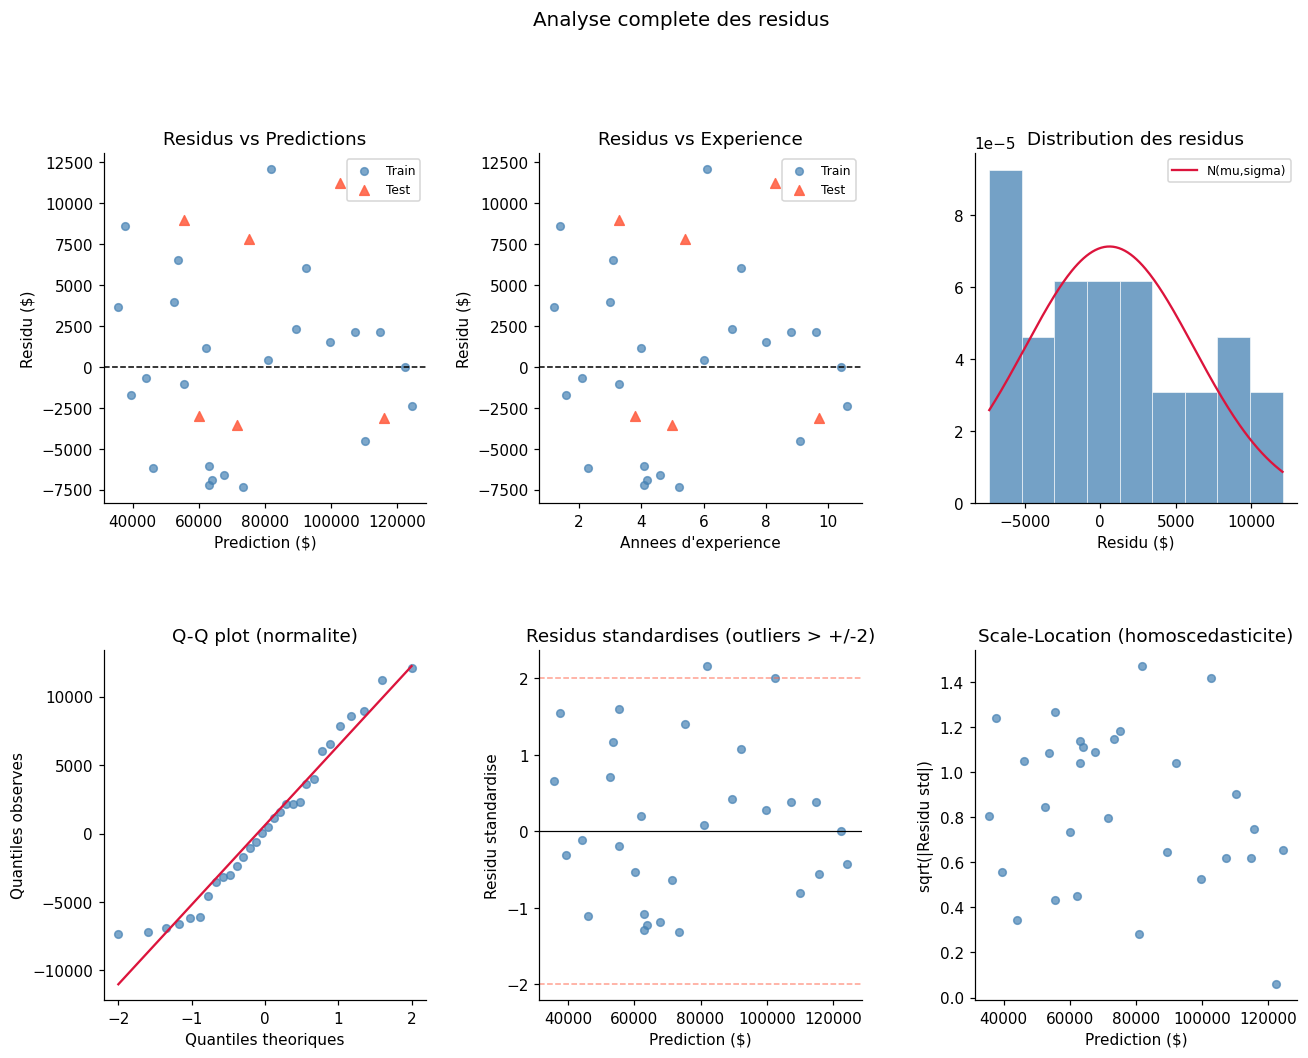

In [13]:
all_res   = np.concatenate([res_train, res_test])
all_preds = np.concatenate([preds_train, preds_test])
all_x_all = np.concatenate([x_train, x_test])

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# 1. Residus vs Predictions
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(preds_train, res_train, s=25, alpha=0.7, color='steelblue', label='Train')
ax1.scatter(preds_test,  res_test,  s=40, alpha=0.9, color='tomato', marker='^', label='Test')
ax1.axhline(0, color='black', lw=1, ls='--')
ax1.set_xlabel('Prediction ($)')
ax1.set_ylabel('Residu ($)')
ax1.set_title('Residus vs Predictions')
ax1.legend(fontsize=8)

# 2. Residus vs Experience
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(x_train, res_train, s=25, alpha=0.7, color='steelblue', label='Train')
ax2.scatter(x_test,  res_test,  s=40, alpha=0.9, color='tomato', marker='^', label='Test')
ax2.axhline(0, color='black', lw=1, ls='--')
ax2.set_xlabel("Annees d'experience")
ax2.set_ylabel('Residu ($)')
ax2.set_title('Residus vs Experience')
ax2.legend(fontsize=8)

# 3. Histogramme des residus
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(all_res, bins=9, color='steelblue', alpha=0.75, edgecolor='white', lw=0.5, density=True)
xg = np.linspace(all_res.min(), all_res.max(), 200)
ax3.plot(xg, stats.norm.pdf(xg, all_res.mean(), all_res.std()), color='crimson', lw=1.5, label='N(mu,sigma)')
ax3.set_xlabel('Residu ($)')
ax3.set_title('Distribution des residus')
ax3.legend(fontsize=8)

# 4. Q-Q plot
ax4 = fig.add_subplot(gs[1, 0])
(osm, osr), (slope, intercept_qq, _) = stats.probplot(all_res, dist='norm')
ax4.scatter(osm, osr, s=25, alpha=0.7, color='steelblue')
ax4.plot(osm, slope * np.array(osm) + intercept_qq, color='crimson', lw=1.5)
ax4.set_xlabel('Quantiles theoriques')
ax4.set_ylabel('Quantiles observes')
ax4.set_title('Q-Q plot (normalite)')

# 5. Residus standardises
ax5 = fig.add_subplot(gs[1, 1])
std_res = all_res / all_res.std()
ax5.scatter(all_preds, std_res, s=25, alpha=0.7, color='steelblue')
ax5.axhline( 2, color='tomato', lw=1, ls='--', alpha=0.6)
ax5.axhline(-2, color='tomato', lw=1, ls='--', alpha=0.6)
ax5.axhline( 0, color='black', lw=0.8)
ax5.set_xlabel('Prediction ($)')
ax5.set_ylabel('Residu standardise')
ax5.set_title('Residus standardises (outliers > +/-2)')

# 6. Scale-Location
ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(all_preds, np.sqrt(np.abs(std_res)), s=25, alpha=0.7, color='steelblue')
ax6.set_xlabel('Prediction ($)')
ax6.set_ylabel('sqrt(|Residu std|)')
ax6.set_title('Scale-Location (homoscedasticite)')

plt.suptitle('Analyse complete des residus', fontsize=13, y=1.01)
plt.show()

In [14]:
# Test de Shapiro-Wilk — H0 : residus normaux
stat_sw, p_sw = stats.shapiro(all_res)
print('Test de Shapiro-Wilk')
print(f'  W       = {stat_sw:.4f}')
print(f'  p-value = {p_sw:.4f}')
if p_sw > 0.05:
    print('  p > 0.05 -> on ne rejette pas H0 : residus compatibles avec une loi normale')
else:
    print('  p <= 0.05 -> H0 rejetee : les residus ne sont pas strictement gaussiens')

# Test de Durbin-Watson — autocorrelation des residus
dw = np.sum(np.diff(all_res)**2) / np.sum(all_res**2)
interp = 'pas d autocorrelation' if 1.5 < dw < 2.5 else 'autocorrelation possible'
print(f'\nDurbin-Watson : {dw:.4f}  ({interp})')

Test de Shapiro-Wilk
  W       = 0.9531
  p-value = 0.2041
  p > 0.05 -> on ne rejette pas H0 : residus compatibles avec une loi normale

Durbin-Watson : 1.8814  (pas d autocorrelation)


## 13. Intervalles de confiance pour w et b

> Sur 30 observations, l'incertitude parametrique est non negligeable.
> On calcule les IC a 95 % via la distribution de Student (df = n - 2).

In [15]:
n       = len(x_train)
df      = n - 2                        # Degres de liberte
preds_tr_ic = w_orig * x_train + b_orig
res_tr_ic   = y_train - preds_tr_ic
s2      = np.sum(res_tr_ic**2) / df   # Variance residuelle
s       = np.sqrt(s2)                 # Ecart-type residuel

x_bar = x_train.mean()
Sxx   = np.sum((x_train - x_bar)**2)

se_w = s / np.sqrt(Sxx)
se_b = s * np.sqrt(1/n + x_bar**2 / Sxx)

t_crit = stats.t.ppf(0.975, df=df)

ic_w = (w_orig - t_crit * se_w, w_orig + t_crit * se_w)
ic_b = (b_orig - t_crit * se_b, b_orig + t_crit * se_b)

print(f"Ecart-type residuel (s)     : {s:,.2f} $")
print(f"t critique (df={df}, 95 %)  : {t_crit:.4f}")
print('-' * 58)
print(f"  w = {w_orig:,.2f}  IC95 % [{ic_w[0]:,.2f} ; {ic_w[1]:,.2f}] $/an")
print(f"  b = {b_orig:,.2f}  IC95 % [{ic_b[0]:,.2f} ; {ic_b[1]:,.2f}] $")
print('-' * 58)
print(f"  Interpretation : avec 95 % de confiance, chaque annee supplementaire")
print(f"  augmente le salaire de {ic_w[0]:,.0f} $ a {ic_w[1]:,.0f} $.")

Ecart-type residuel (s)     : 5,437.48 $
t critique (df=22, 95 %)  : 2.0739
----------------------------------------------------------
  w = 9,420.81  IC95 % [8,621.88 ; 10,219.73] $/an
  b = 24,396.10  IC95 % [19,585.35 ; 29,206.85] $
----------------------------------------------------------
  Interpretation : avec 95 % de confiance, chaque annee supplementaire
  augmente le salaire de 8,622 $ a 10,220 $.


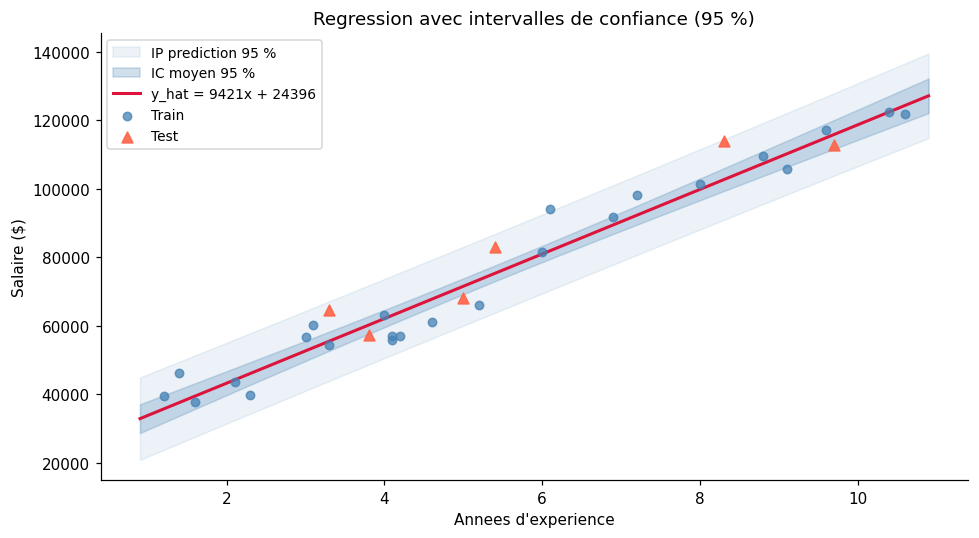

In [16]:
# Bande de confiance 95 % et intervalle de prediction
x_plot = np.linspace(x.min() - 0.3, x.max() + 0.3, 300)
y_plot = w_orig * x_plot + b_orig

se_mean = s * np.sqrt(1/n + (x_plot - x_bar)**2 / Sxx)
ic_up   = y_plot + t_crit * se_mean
ic_lo   = y_plot - t_crit * se_mean

se_pred = s * np.sqrt(1 + 1/n + (x_plot - x_bar)**2 / Sxx)
ip_up   = y_plot + t_crit * se_pred
ip_lo   = y_plot - t_crit * se_pred

plt.figure(figsize=(9, 5))
plt.fill_between(x_plot, ip_lo, ip_up, color='steelblue', alpha=0.10, label='IP prediction 95 %')
plt.fill_between(x_plot, ic_lo, ic_up, color='steelblue', alpha=0.25, label='IC moyen 95 %')
plt.plot(x_plot, y_plot, color='crimson', lw=2, label=f"y_hat = {w_orig:.0f}x + {b_orig:.0f}")
plt.scatter(x_train, y_train, s=30, alpha=0.75, color='steelblue', label='Train', zorder=4)
plt.scatter(x_test,  y_test,  s=50, alpha=0.90, color='tomato', marker='^', label='Test', zorder=5)
plt.xlabel("Annees d'experience")
plt.ylabel('Salaire ($)')
plt.title('Regression avec intervalles de confiance (95 %)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 14. Prediction avec validation & intervalle de prediction

In [17]:
EXP_MIN = float(x_train.min())
EXP_MAX = float(x_train.max())


def predict(years_experience, confidence=0.95):
    """
    Predit le salaire avec intervalle de prediction.

    Parametres
    ----------
    years_experience : float  -- annees d'experience (dans la plage d'entrainement)
    confidence       : float  -- niveau de confiance pour l'IP (defaut 0.95)

    Retourne
    --------
    dict : {prediction, ip_lower, ip_upper}
    """
    if not isinstance(years_experience, (int, float)):
        raise TypeError(f"Attendu un nombre, recu : {type(years_experience).__name__}")
    if not (EXP_MIN <= years_experience <= EXP_MAX):
        raise ValueError(
            f"Hors plage : {years_experience} ans — modele valide entre {EXP_MIN} et {EXP_MAX} ans."
        )
    yhat   = w_orig * years_experience + b_orig
    alpha  = 1 - confidence
    t_val  = stats.t.ppf(1 - alpha / 2, df=df)
    se_ip  = s * np.sqrt(1 + 1/n + (years_experience - x_bar)**2 / Sxx)
    margin = t_val * se_ip
    return {'prediction': yhat, 'ip_lower': yhat - margin, 'ip_upper': yhat + margin}


print(f"Plage valide : {EXP_MIN:.2f} – {EXP_MAX:.2f} annees")
print()
for exp in [3.8, 6.0, 9.5]:
    r = predict(exp)
    print(f"  {exp} ans -> y_hat = {r['prediction']:,.0f} $   IP95 % [{r['ip_lower']:,.0f} ; {r['ip_upper']:,.0f}] $")
print()
try:
    predict(150.0)
except ValueError as e:
    print(f"  predict(150.0) -> ValueError : {e}")
try:
    predict('cinq')
except TypeError as e:
    print(f"  predict('cinq') -> TypeError : {e}")

Plage valide : 1.20 – 10.60 annees

  3.8 ans -> y_hat = 60,195 $   IP95 % [48,625 ; 71,766] $
  6.0 ans -> y_hat = 80,921 $   IP95 % [69,398 ; 92,444] $
  9.5 ans -> y_hat = 113,894 $   IP95 % [101,903 ; 125,885] $

  predict(150.0) -> ValueError : Hors plage : 150.0 ans — modele valide entre 1.2000000000000002 et 10.6 ans.
  predict('cinq') -> TypeError : Attendu un nombre, recu : str


## 15. Synthese & limites du modele

### Equation finale

$$\hat{y} = 9\,420.81 \times x_{\text{exp}} + 24\,396.10$$

**Interpretation :** chaque annee d'experience supplementaire est associee en moyenne a une augmentation de **~9 421 $** de salaire.

### Resultats cles

| Metrique | Train | Test (hold-out) | CV 5-fold |
|---|---|---|---|
| R2 | 0.9645 | 0.9024 | mu +/- sigma (voir cellule 10) |
| RMSE | 5 206 $ | 7 060 $ | mu +/- sigma (voir cellule 10) |
| MAE | 4 223 $ | 6 286 $ | mu +/- sigma (voir cellule 10) |

### Limites

- **Taille du dataset (n = 30) :** les metriques restent sensibles a la composition de l'ensemble test. La validation croisee corrige partiellement ce biais.
- **Variable unique :** le salaire depend de nombreux autres facteurs (secteur, diplome, localisation, poste) absents de ce dataset.
- **Lineraite :** la relation semble lineaire sur 1.2–10.6 ans ; l'extrapolation est deconseilee.
- **Homoscedasticite :** verifier le Q-Q plot et Shapiro-Wilk (cellule 12).